In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [12]:
# Make the corner plot for the MCMC results
system_name = 'J2344'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z',  'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [13]:
samples

,chi2,z,vel_disp,x,y,ellip,pa
0,5.432064,0.295100,157.8627,0.443815,-0.167121,0.327969,-109.4547
1,5.759494,0.295895,157.7863,0.443161,-0.167147,0.320119,-109.4206
2,6.314107,0.294609,158.1047,0.442742,-0.165597,0.326797,-109.4168
3,7.639398,0.296864,158.1795,0.437515,-0.165489,0.329072,-109.3783
4,6.557901,0.293283,157.3762,0.440689,-0.165231,0.322876,-109.4244
...,...,...,...,...,...,...,...
1940,19.485740,0.184164,148.2784,0.449891,-0.168266,0.344637,-108.8256
1941,11.050470,0.192398,148.0078,0.448104,-0.166163,0.346788,-108.8769
1942,12.610500,0.200339,149.0234,0.448817,-0.168928,0.342538,-108.8033
1943,18.249780,0.196134,149.1173,0.446555,-0.171810,0.340878,-108.7838


In [14]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [15]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

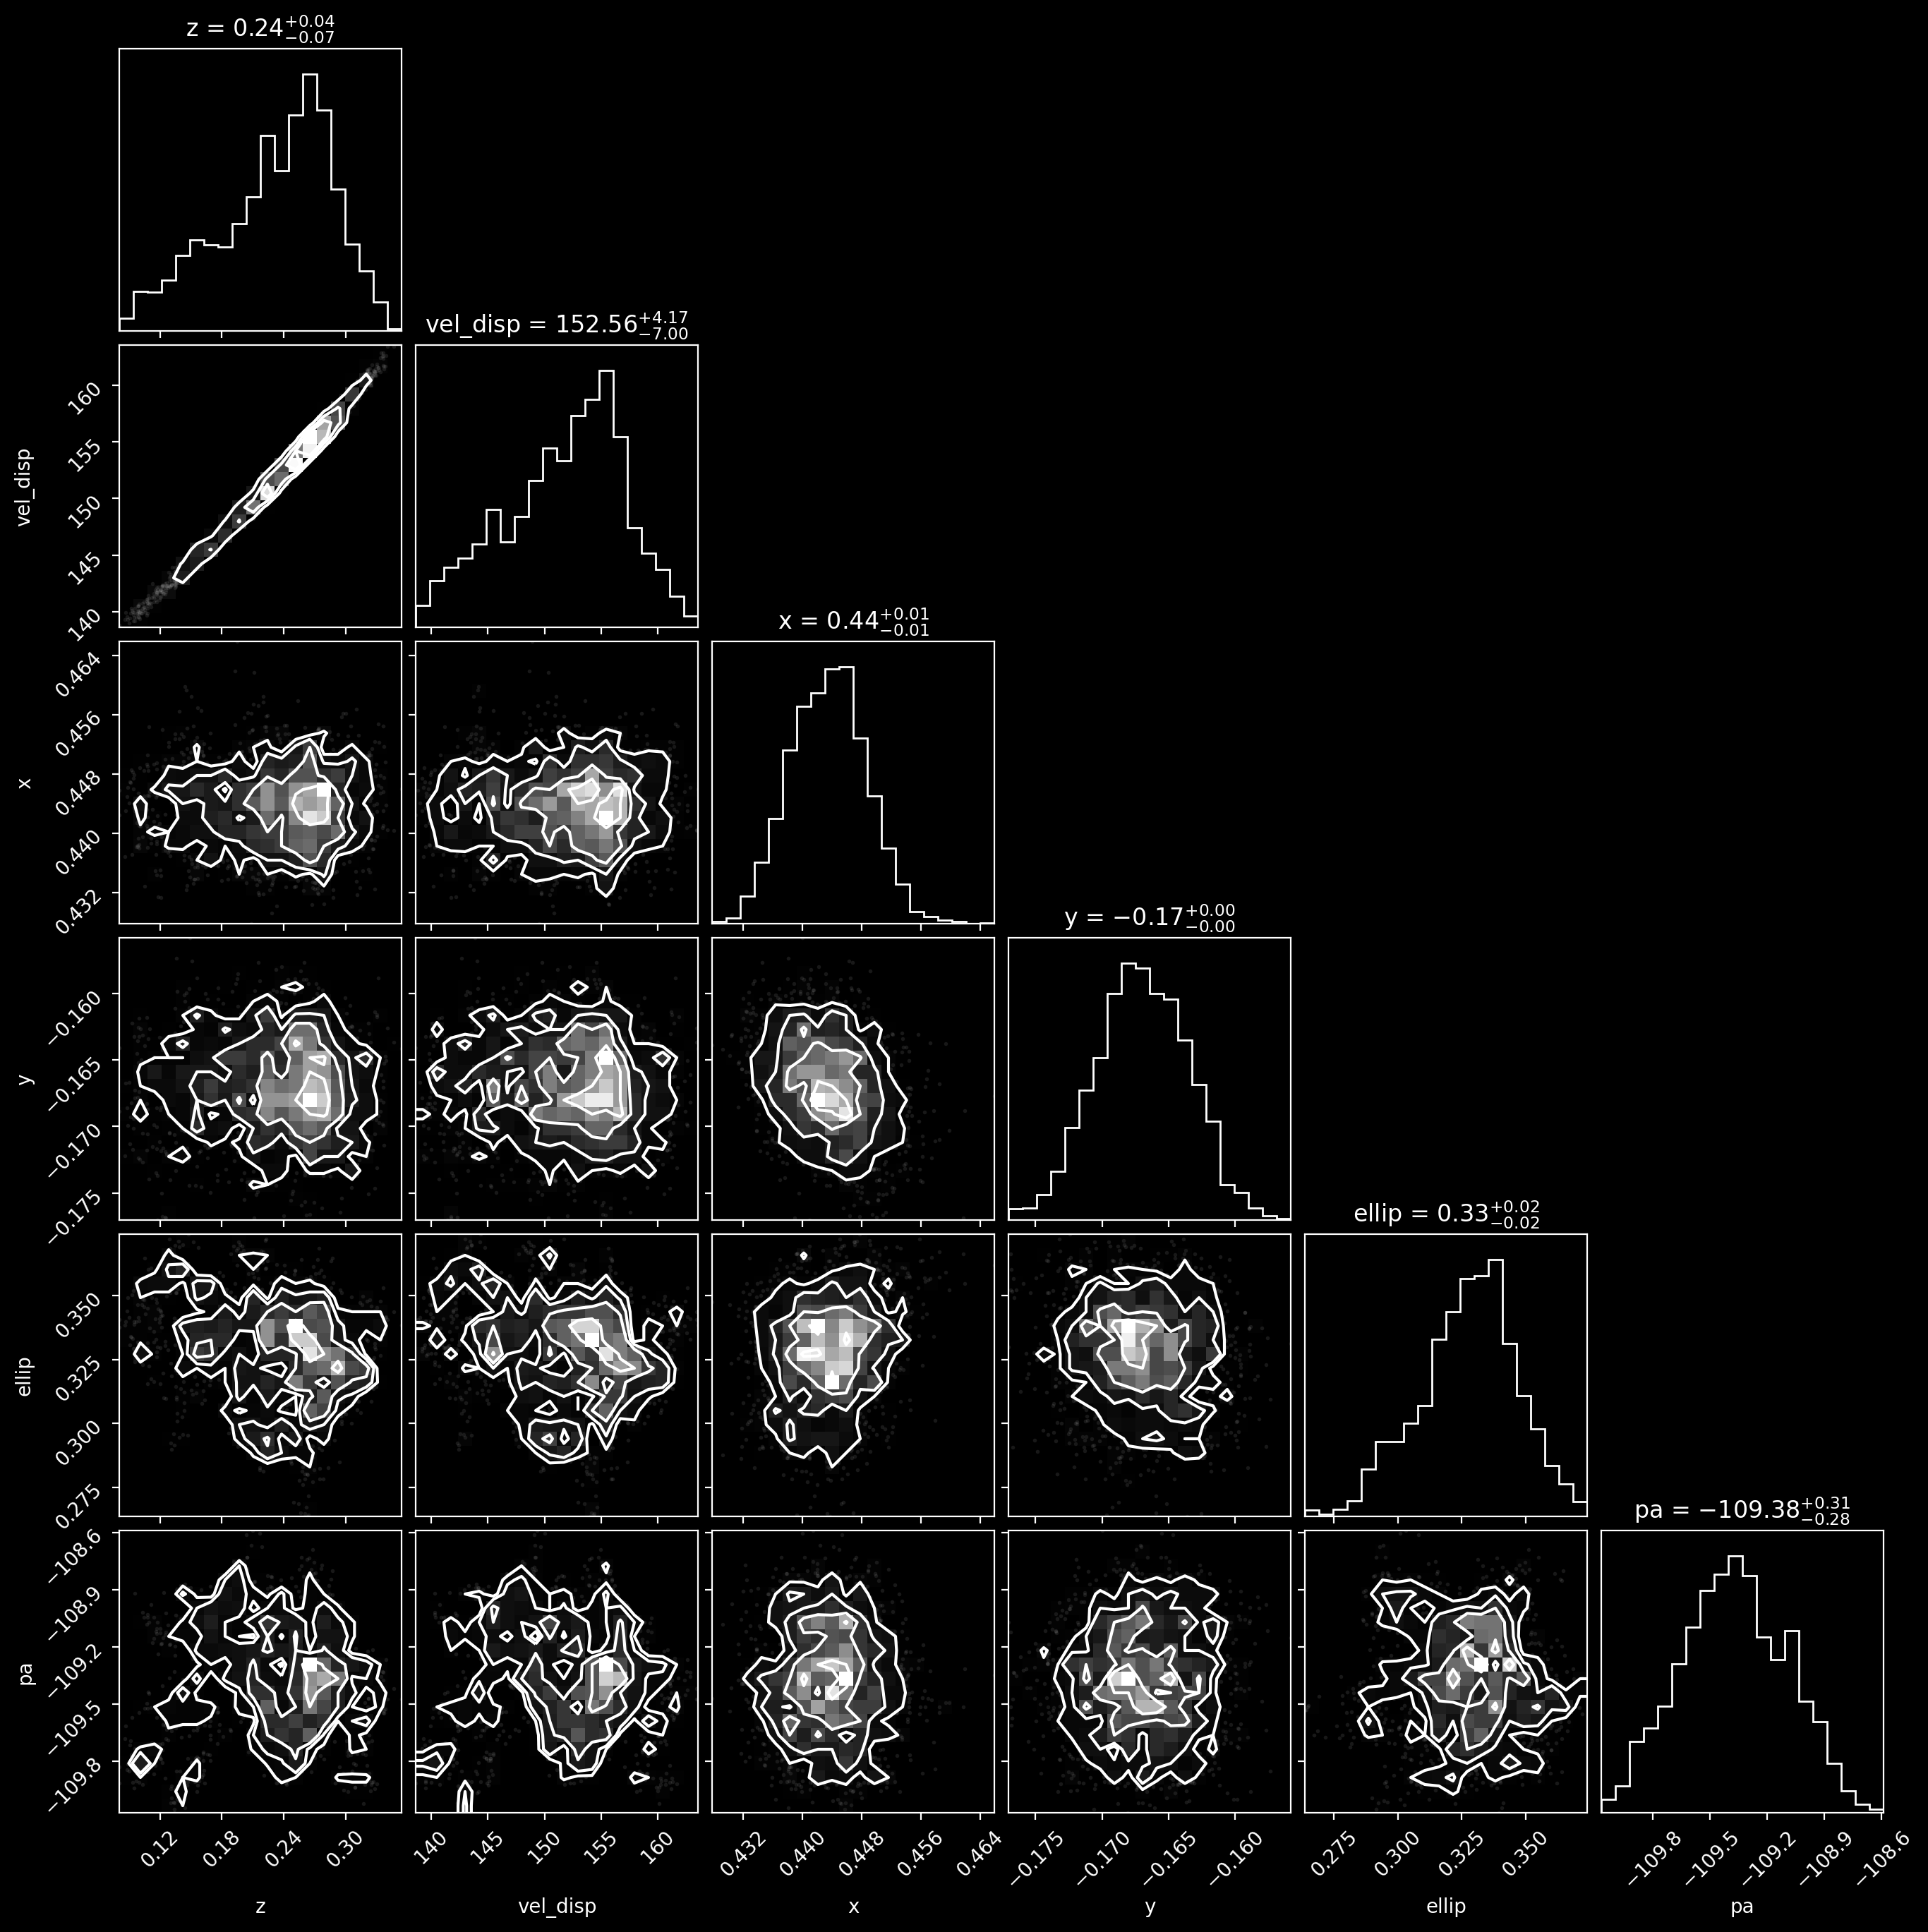

In [16]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')